**Phase 1: Column Understanding**

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df=pd.read_csv('/content/drive/MyDrive/flipkartGridlock2.0/round2/dataset/jan to may police violation_anonymized791b166.csv')

In [4]:
print(df.shape)
print(df.columns)
print(df.info())

(298450, 24)
Index(['id', 'latitude', 'longitude', 'location', 'vehicle_number',
       'vehicle_type', 'description', 'violation_type', 'offence_code',
       'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id',
       'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita',
       'junction_name', 'action_taken_timestamp',
       'data_sent_to_scita_timestamp', 'updated_vehicle_number',
       'updated_vehicle_type', 'validation_status', 'validation_timestamp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4 

In [5]:
audit = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Non Null Count": df.notnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2),
    "Unique Values": df.nunique(),
    "Example Value": [
        df[col].dropna().iloc[0]
        if len(df[col].dropna()) > 0
        else None
        for col in df.columns
    ]
})

audit

,Data Type,Non Null Count,Missing %,Unique Values,Example Value
id,object,298450,0.00,298450,FKID000000
latitude,float64,298450,0.00,177982,12.925557
longitude,float64,298450,0.00,177378,77.618665
location,object,295409,1.02,10942,"18th Main Road, Block 2, Koramangala, Bengalur..."
vehicle_number,object,298450,0.00,231890,FKN00GL0000
vehicle_type,object,298450,0.00,22,CAR
description,float64,0,100.00,0,None
violation_type,object,298450,0.00,991,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]"
offence_code,object,298450,0.00,991,"[112,104]"
created_datetime,object,298450,0.00,94417,2023-11-20 00:28:46+00


In [6]:
audit["Business Meaning"] = ""
audit["Decision Value"] = ""
audit["Predictive Value"] = ""
audit["Importance"] = ""

audit

,Data Type,Non Null Count,Missing %,Unique Values,Example Value,Business Meaning,Decision Value,Predictive Value,Importance
id,object,298450,0.00,298450,FKID000000,,,,
latitude,float64,298450,0.00,177982,12.925557,,,,
longitude,float64,298450,0.00,177378,77.618665,,,,
location,object,295409,1.02,10942,"18th Main Road, Block 2, Koramangala, Bengalur...",,,,
vehicle_number,object,298450,0.00,231890,FKN00GL0000,,,,
vehicle_type,object,298450,0.00,22,CAR,,,,
description,float64,0,100.00,0,None,,,,
violation_type,object,298450,0.00,991,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]",,,,
offence_code,object,298450,0.00,991,"[112,104]",,,,
created_datetime,object,298450,0.00,94417,2023-11-20 00:28:46+00,,,,


In [7]:
column_info = {
    "id": {
        "Business Meaning": "Unique violation record",
        "Decision Value": "None",
        "Predictive Value": "None",
        "Importance": "Low"
    },

    "latitude": {
        "Business Meaning": "Exact location where violation occurred",
        "Decision Value": "Identify hotspot regions",
        "Predictive Value": "Future violation locations",
        "Importance": "Very High"
    },

    "longitude": {
        "Business Meaning": "Exact location where violation occurred",
        "Decision Value": "Identify hotspot regions",
        "Predictive Value": "Future hotspot locations",
        "Importance": "Very High"
    },

    "location": {
        "Business Meaning": "Human-readable violation address",
        "Decision Value": "Identify problematic roads",
        "Predictive Value": "Extract commercial zones",
        "Importance": "High"
    },

    "vehicle_number": {
        "Business Meaning": "Vehicle identifier",
        "Decision Value": "Repeat offender detection",
        "Predictive Value": "Recurring violators",
        "Importance": "Medium"
    },

    "vehicle_type": {
        "Business Meaning": "Type of vehicle",
        "Decision Value": "Which vehicle category causes most blockage",
        "Predictive Value": "Violation likelihood by vehicle class",
        "Importance": "High"
    },

    "description": {
        "Business Meaning": "-",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Ignore"
    },

    "violation_type": {
        "Business Meaning": "Nature of parking offence",
        "Decision Value": "Prioritize severe violations",
        "Predictive Value": "Hotspot severity prediction",
        "Importance": "Extremely High"
    },

    "offence_code": {
        "Business Meaning": "Legal violation category",
        "Decision Value": "Enforcement priority",
        "Predictive Value": "Violation patterns",
        "Importance": "Medium"
    },

    "created_datetime": {
        "Business Meaning": "Time violation recorded",
        "Decision Value": "Officer deployment planning",
        "Predictive Value": "Future hotspot timing",
        "Importance": "Extremely High"
    },

    "closed_datetime": {
        "Business Meaning": "-",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Ignore"
    },

    "modified_datetime": {
        "Business Meaning": "Last update time",
        "Decision Value": "Workflow monitoring",
        "Predictive Value": "Weak",
        "Importance": "Low"
    },

    "device_id": {
        "Business Meaning": "Officer device used",
        "Decision Value": "Productivity tracking",
        "Predictive Value": "Limited",
        "Importance": "Low-Medium"
    },

    "created_by_id": {
        "Business Meaning": "Officer who recorded violation",
        "Decision Value": "Enforcement coverage",
        "Predictive Value": "Weak",
        "Importance": "Low"
    },

    "center_code": {
        "Business Meaning": "Traffic control center",
        "Decision Value": "Enforcement zone",
        "Predictive Value": "Limited",
        "Importance": "Medium"
    },

    "police_station": {
        "Business Meaning": "Jurisdiction handling violation",
        "Decision Value": "Resource allocation",
        "Predictive Value": "Hotspot prediction",
        "Importance": "Very High"
    },

    "data_sent_to_scita": {
        "Business Meaning": "Likely workflow-related",
        "Decision Value": "Likely workflow-related",
        "Predictive Value": "Limited",
        "Importance": "Low-Medium"
    },

    "junction_name": {
        "Business Meaning": "Nearby intersection",
        "Decision Value": "Congestion risk estimation",
        "Predictive Value": "Future hotspot prediction",
        "Importance": "Very High"
    },

    "action_taken_timestamp": {
        "Business Meaning": "Mostly null",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Low"
    },

    "data_sent_to_scita_timestamp": {
        "Business Meaning": "Workflow-field",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Low"
    },

    "updated_vehicle_number": {
        "Business Meaning": "Legal violation category",
        "Decision Value": "Enforcement priority",
        "Predictive Value": "Violation patterns",
        "Importance": "Medium"
    },

    "updated_vehicle_type": {
        "Business Meaning": "Potential Correction field",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Low"
    },

    "validation_status": {
        "Business Meaning": "Violation verification outcome",
        "Decision Value": "Data quality",
        "Predictive Value": "Weak",
        "Importance": "Medium"
    },

    "validation_timestamp": {
        "Business Meaning": "Timestamp of verification.",
        "Decision Value": "-",
        "Predictive Value": "-",
        "Importance": "Low-Medium"
    }
}

In [8]:
for col, values in column_info.items():
    for field, value in values.items():
        audit.loc[col, field] = value

In [9]:
audit

,Data Type,Non Null Count,Missing %,Unique Values,Example Value,Business Meaning,Decision Value,Predictive Value,Importance
id,object,298450,0.00,298450,FKID000000,Unique violation record,None,None,Low
latitude,float64,298450,0.00,177982,12.925557,Exact location where violation occurred,Identify hotspot regions,Future violation locations,Very High
longitude,float64,298450,0.00,177378,77.618665,Exact location where violation occurred,Identify hotspot regions,Future hotspot locations,Very High
location,object,295409,1.02,10942,"18th Main Road, Block 2, Koramangala, Bengalur...",Human-readable violation address,Identify problematic roads,Extract commercial zones,High
vehicle_number,object,298450,0.00,231890,FKN00GL0000,Vehicle identifier,Repeat offender detection,Recurring violators,Medium
vehicle_type,object,298450,0.00,22,CAR,Type of vehicle,Which vehicle category causes most blockage,Violation likelihood by vehicle class,High
description,float64,0,100.00,0,None,-,-,-,Ignore
violation_type,object,298450,0.00,991,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]",Nature of parking offence,Prioritize severe violations,Hotspot severity prediction,Extremely High
offence_code,object,298450,0.00,991,"[112,104]",Legal violation category,Enforcement priority,Violation patterns,Medium
created_datetime,object,298450,0.00,94417,2023-11-20 00:28:46+00,Time violation recorded,Officer deployment planning,Future hotspot timing,Extremely High


**Phase 2: Exploratory Data Analysis (EDA)**

A. Violation Distribution

In [10]:
df['violation_type'].value_counts()

,count
violation_type,
"[""WRONG PARKING""]",138764
"[""NO PARKING""]",119576
"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]",9472
"[""PARKING IN A MAIN ROAD"",""NO PARKING""]",4818
"[""WRONG PARKING"",""DEFECTIVE NUMBER PLATE""]",3317
...,...
"[""NO PARKING"",""PARKING IN A MAIN ROAD"",""PARKING NEAR ROAD CROSSING"",""PARKING OPPOSITE TO ANOTHER PARKED VEHICLE"",""WRONG PARKING""]",1
"[""NO PARKING"",""PARKING ON FOOTPATH"",""PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS"",""DEFECTIVE NUMBER PLATE""]",1
"[""PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS"",""PARKING IN A MAIN ROAD"",""DOUBLE PARKING"",""NO PARKING""]",1


B. Time Analysis

In [11]:
df['created_datetime'] = pd.to_datetime(
    df['created_datetime'],
    format='mixed',
    errors='coerce'
)

In [12]:
df['created_datetime'].isnull().sum()

np.int64(0)

In [13]:
df['created_datetime'].min(), df['created_datetime'].max()

(Timestamp('2023-11-09 19:11:46+0000', tz='UTC'),
 Timestamp('2024-04-08 17:30:46+0000', tz='UTC'))

In [14]:
df['weekday'] = df['created_datetime'].dt.day_name()
df['month'] = df['created_datetime'].dt.month_name()
df['date'] = df['created_datetime'].dt.date

In [15]:
df.groupby('weekday').size()

,0
weekday,
Friday,41702
Monday,38931
Saturday,43427
Sunday,46865
Thursday,41528
Tuesday,42930
Wednesday,43067


In [16]:
df.groupby('month').size()

,0
month,
April,15082
December,63555
February,54650
January,65813
March,55231
November,44119


In [17]:
df['hour'] = df['created_datetime'].dt.hour

hourly = (
    df.groupby('hour')
      .size()
      .sort_index()
)

hourly

,0
hour,
0,21762
1,17155
2,24770
3,25709
4,29102
5,34085
6,26890
7,14608
8,8556


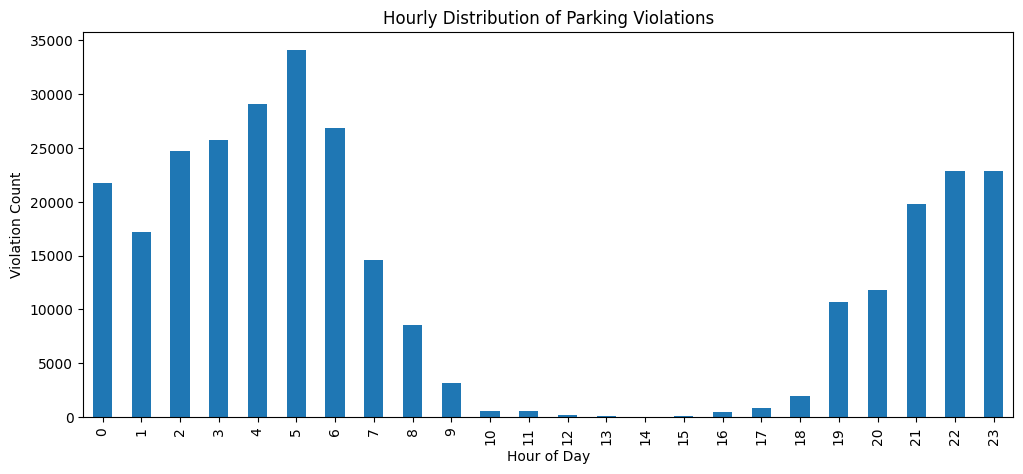

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

hourly.plot(
    kind='bar'
)

plt.title('Hourly Distribution of Parking Violations')
plt.xlabel('Hour of Day')
plt.ylabel('Violation Count')

plt.show()

In [19]:
df.groupby('hour').size().sort_values(ascending=False)

,0
hour,
5,34085
4,29102
6,26890
3,25709
2,24770
23,22861
22,22840
0,21762
21,19763


In [20]:
df[['created_datetime']].sample(20)

,created_datetime
266584,2024-01-16 01:13:46+00:00
216965,2023-12-31 05:15:46+00:00
234616,2024-01-04 19:33:46+00:00
253654,2024-01-19 05:04:46+00:00
93302,2024-03-06 22:04:46+00:00
209578,2023-12-28 00:24:46+00:00
157263,2023-12-07 07:50:46+00:00
180534,2023-12-11 05:59:46+00:00
44188,2024-02-15 19:24:46+00:00
111698,2024-03-19 00:17:46+00:00


In [21]:
df.groupby('hour').size()

,0
hour,
0,21762
1,17155
2,24770
3,25709
4,29102
5,34085
6,26890
7,14608
8,8556


In [22]:
(
    df.groupby(['junction_name','hour'])
      .size()
      .sort_values(ascending=False)
      .head(20)
)

junction_name                   hour
No Junction                     5       16964
                                6       14680
                                22      12878
                                4       12269
                                23      12089
                                2       11072
                                21      10886
                                0       10371
                                3       10312
                                7        9182
                                1        8333
                                20       6065
                                8        5177
                                19       4090
BTP051 - Safina Plaza Junction  5        2972
                                4        2696
                                2        2023
                                3        2003
                                6        1863
BTP082 - KR Market Junction     19       1788
dtype: int64

C. Location Analysis

In [23]:
df['junction_name'].value_counts().head(20)

,count
junction_name,
No Junction,147880
BTP051 - Safina Plaza Junction,15449
BTP082 - KR Market Junction,11538
BTP040 - Elite Junction,10718
BTP044 - Sagar Theatre Junction,10549
BTP211 - Central Street Junction,5388
BTP058 - Subbanna Junction,5189
BTP027 - Modi Bridge Junction,4584
BTP020 - Hosahalli Metro Station,4101


In [24]:
junction_df = df[
    (df['junction_name'].notna()) &
    (df['junction_name'] != 'No Junction')
]

In [25]:
(
    junction_df
    .groupby('junction_name')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

,0
junction_name,
BTP051 - Safina Plaza Junction,15449
BTP082 - KR Market Junction,11538
BTP040 - Elite Junction,10718
BTP044 - Sagar Theatre Junction,10549
BTP211 - Central Street Junction,5388
BTP058 - Subbanna Junction,5189
BTP027 - Modi Bridge Junction,4584
BTP020 - Hosahalli Metro Station,4101
BTP057 - Anand Rao Junction,3935


In [26]:
(
    junction_df
    .groupby(['junction_name','hour'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

junction_name                    hour
BTP051 - Safina Plaza Junction   5       2972
                                 4       2696
                                 2       2023
                                 3       2003
                                 6       1863
BTP082 - KR Market Junction      19      1788
BTP040 - Elite Junction          3       1717
BTP044 - Sagar Theatre Junction  3       1677
                                 4       1457
BTP040 - Elite Junction          4       1419
BTP058 - Subbanna Junction       19      1390
BTP082 - KR Market Junction      4       1178
BTP044 - Sagar Theatre Junction  5       1154
BTP040 - Elite Junction          5       1112
BTP082 - KR Market Junction      5       1036
BTP044 - Sagar Theatre Junction  2       1000
BTP082 - KR Market Junction      3        970
BTP051 - Safina Plaza Junction   7        965
BTP040 - Elite Junction          2        959
                                 0        935
dtype: int64

In [27]:
(
    junction_df
    .groupby(['junction_name','police_station'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

,,0
junction_name,police_station,
BTP051 - Safina Plaza Junction,Shivajinagar,15298
BTP040 - Elite Junction,Upparpet,10718
BTP082 - KR Market Junction,City Market,10109
BTP044 - Sagar Theatre Junction,Upparpet,10049
BTP211 - Central Street Junction,Shivajinagar,5373
BTP058 - Subbanna Junction,Upparpet,4830
BTP020 - Hosahalli Metro Station,Vijayanagara,4035
BTP057 - Anand Rao Junction,Upparpet,3641
"BTP080 - NR Road, SP Road Junction",Halasuru Gate,3283


In [28]:
(
    junction_df
    .groupby(['junction_name','violation_type'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

,,0
junction_name,violation_type,
BTP082 - KR Market Junction,"[""WRONG PARKING""]",9329
BTP051 - Safina Plaza Junction,"[""WRONG PARKING""]",8281
BTP040 - Elite Junction,"[""NO PARKING""]",5576
BTP051 - Safina Plaza Junction,"[""NO PARKING""]",5522
BTP044 - Sagar Theatre Junction,"[""NO PARKING""]",5204
BTP040 - Elite Junction,"[""WRONG PARKING""]",4805
BTP044 - Sagar Theatre Junction,"[""WRONG PARKING""]",4747
BTP058 - Subbanna Junction,"[""NO PARKING""]",3118
BTP211 - Central Street Junction,"[""WRONG PARKING""]",2964


In [29]:
(
    junction_df
    .groupby(['junction_name','vehicle_type'])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

,,0
junction_name,vehicle_type,
BTP051 - Safina Plaza Junction,SCOOTER,5297
BTP082 - KR Market Junction,SCOOTER,5203
BTP051 - Safina Plaza Junction,PASSENGER AUTO,4959
BTP040 - Elite Junction,SCOOTER,4816
BTP044 - Sagar Theatre Junction,SCOOTER,3843
BTP058 - Subbanna Junction,CAR,3292
BTP044 - Sagar Theatre Junction,CAR,3206
BTP051 - Safina Plaza Junction,CAR,3060
BTP211 - Central Street Junction,PASSENGER AUTO,3050


D. Police Station Analysis

In [30]:
df['police_station'].value_counts()

,count
police_station,
Upparpet,34468
Shivajinagar,28044
Malleshwaram,22200
HAL Old Airport,20819
City Market,17646
Vijayanagara,14652
Rajajinagar,10998
Kodigehalli,10916
Magadi Road,8558


In [31]:
junction_df.groupby(
    ['police_station','hour']
).size().sort_values(ascending=False).head(30)

police_station  hour
Upparpet        3       4720
                4       4022
Shivajinagar    5       3782
                4       3483
Upparpet        5       3333
                2       2935
Shivajinagar    3       2827
Upparpet        0       2652
Shivajinagar    2       2620
Upparpet        19      2553
Shivajinagar    6       2502
Upparpet        23      2370
                6       2253
City Market     19      2028
Upparpet        1       1986
                20      1943
Vijayanagara    5       1774
Upparpet        21      1740
City Market     4       1619
Upparpet        22      1571
Vijayanagara    23      1529
                4       1517
City Market     5       1416
                3       1414
                2       1393
Vijayanagara    3       1393
                22      1367
Shivajinagar    7       1285
City Market     0       1268
Shivajinagar    0       1234
dtype: int64

In [32]:
junction_df.groupby(
    ['junction_name','weekday']
).size().sort_values(ascending=False).head(30)

junction_name                     weekday  
BTP051 - Safina Plaza Junction    Sunday       4115
                                  Monday       2778
                                  Saturday     2115
BTP044 - Sagar Theatre Junction   Sunday       2044
BTP051 - Safina Plaza Junction    Friday       1924
BTP082 - KR Market Junction       Sunday       1901
                                  Wednesday    1835
BTP040 - Elite Junction           Saturday     1766
BTP082 - KR Market Junction       Thursday     1687
BTP040 - Elite Junction           Sunday       1675
BTP082 - KR Market Junction       Tuesday      1671
                                  Saturday     1649
BTP040 - Elite Junction           Monday       1599
BTP044 - Sagar Theatre Junction   Saturday     1598
BTP082 - KR Market Junction       Monday       1583
BTP051 - Safina Plaza Junction    Tuesday      1580
BTP040 - Elite Junction           Tuesday      1561
BTP044 - Sagar Theatre Junction   Tuesday      1549
BTP040 - Elite Junction           Friday       1519
BTP051 - Safina Plaza Junction    Thursday     1479
                                  Wednesday    1458
BTP040 - Elite Junction           Thursday     1394
BTP044 - Sagar Theatre Junction   Wednesday    1368
                                  Friday       1355
                                  Thursday     1325
                                  Monday       1310
BTP082 - KR Market Junction       Friday       1212
BTP040 - Elite Junction           Wednesday    1204
BTP211 - Central Street Junction  Sunday       1136
                                  Monday        977
dtype: int64

In [33]:
junction_df.groupby(
    ['junction_name','month']
).size().sort_values(ascending=False).head(30)

junction_name                     month   
BTP051 - Safina Plaza Junction    January     3612
                                  November    3269
                                  March       2980
BTP082 - KR Market Junction       January     2815
                                  March       2648
BTP044 - Sagar Theatre Junction   January     2530
BTP051 - Safina Plaza Junction    February    2489
BTP040 - Elite Junction           December    2467
BTP051 - Safina Plaza Junction    December    2409
BTP082 - KR Market Junction       February    2394
BTP040 - Elite Junction           January     2188
BTP082 - KR Market Junction       December    2104
BTP040 - Elite Junction           March       2025
BTP044 - Sagar Theatre Junction   December    1990
                                  February    1932
BTP211 - Central Street Junction  January     1799
BTP044 - Sagar Theatre Junction   November    1782
BTP040 - Elite Junction           November    1740
BTP044 - Sagar Theatre Junction   March       1728
BTP040 - Elite Junction           February    1608
BTP020 - Hosahalli Metro Station  December    1258
BTP058 - Subbanna Junction        December    1222
BTP027 - Modi Bridge Junction     December    1150
BTP032 - Windsor Circle           December    1111
BTP211 - Central Street Junction  March       1093
BTP082 - KR Market Junction       November    1044
BTP057 - Anand Rao Junction       December    1021
BTP058 - Subbanna Junction        January     1011
BTP020 - Hosahalli Metro Station  January     1005
BTP058 - Subbanna Junction        November     952
dtype: int64

**Phase 3: Operational Thinking**

### Operational Insight 1

**Finding**
Wrong Parking accounts for nearly half of all recorded parking violations.

**Interpretation**
Most congestion appears to be caused by vehicles occupying unauthorized roadside space rather than parking in explicitly prohibited zones.

**Why Traffic Police Care**
Recurring wrong parking suggests weak deterrence and creates unpredictable lane blockages that reduce effective road capacity.

**Recommended Action**
Increase camera-based enforcement and towing operations in recurring wrong-parking hotspots.

**Expected Impact**
Improved lane availability and reduced localized congestion.

### Operational Insight 2

**Finding**
Parking violations are highest on weekends, especially Sundays.

**Interpretation**
Violation activity is driven more by recreational and commercial travel than office commuting.

**Why Traffic Police Care**
Traditional weekday-focused enforcement may miss a significant portion of parking-related congestion.

**Recommended Action**
Increase patrol presence around shopping districts, entertainment zones, and transit hubs on weekends.

**Expected Impact**
Reduction in weekend traffic bottlenecks caused by spillover parking.

### Operational Insight 3

**Finding**
Violation counts peak during December and January.

**Interpretation**
Holiday travel, shopping activity, and public events likely increase parking demand.

**Why Traffic Police Care**
Parking-induced congestion is seasonal and may require temporary resource reallocation.

**Recommended Action**
Deploy additional enforcement teams during holiday seasons and major city events.

**Expected Impact**
Better congestion management during high-demand periods.

### Operational Insight 4

**Finding**
A small number of junctions account for a disproportionately large share of parking violations.

**Interpretation**
Parking violations are spatially concentrated rather than uniformly distributed across the city.

**Why Traffic Police Care**
Targeting a few high-risk junctions could yield significantly greater congestion reduction than city-wide enforcement.

**Recommended Action**
Establish hotspot-based enforcement zones around the top 10 violation-generating junctions.

**Expected Impact**
Higher enforcement efficiency and greater reduction in parking-induced congestion.

### Operational Insight 5

**Finding**
Metro station areas appear among the highest violation locations.

**Interpretation**
Transit hubs generate spillover parking demand that exceeds available parking capacity.

**Why Traffic Police Care**
Illegal parking near transit hubs can block feeder roads and reduce accessibility.

**Recommended Action**
Introduce dynamic enforcement and evaluate additional parking infrastructure around metro stations.

**Expected Impact**
Improved transit access and reduced congestion near station approaches.

### Operational Insight 6

**Finding**
Violation volume is heavily concentrated in a few police jurisdictions.

**Interpretation**
Parking enforcement demand is unevenly distributed across Bengaluru.

**Why Traffic Police Care**
Uniform allocation of enforcement personnel may lead to inefficient resource utilization.

**Recommended Action**
Allocate officers dynamically based on hotspot intensity and violation density.

**Expected Impact**
Improved enforcement productivity without increasing manpower.

### Operational Insight 7

The temporal distribution of violations shows unusually high concentrations during late-night and early-morning hours (12 AM–6 AM) and near-zero activity during midday.

This pattern does not align with expected urban parking behavior and suggests that `created_datetime` may represent record creation or synchronization time rather than the actual violation occurrence time.

Implication:
Before using this field for predictive modeling, its operational meaning should be validated. Misinterpreting administrative timestamps as violation timestamps could lead to incorrect deployment recommendations.:

### Operational Insight 8

Parking violations are not uniformly distributed across Bengaluru.

A small set of high-risk junctions contributes a disproportionately large share of violations, suggesting that congestion mitigation efforts should prioritize hotspot-based enforcement rather than city-wide uniform patrols.

Recommended Action:
Create a dynamic hotspot watchlist and allocate enforcement resources based on violation density.

### Operational Insight 9

Different junctions exhibit distinct temporal violation patterns.

This suggests that enforcement schedules should be location-specific rather than applying the same patrol timing citywide.

For example:
- KR Market requires evening monitoring.
- Safina Plaza shows recurring early-morning activity.
- Metro-associated locations may require commuter-hour enforcement.

Recommended Action:
Generate location-specific enforcement schedules using historical violation patterns.

### Operational Insight 10

Major violation hotspots are strongly associated with specific police jurisdictions.

This enables accountability and targeted resource allocation.

Recommended Action:
Provide hotspot risk scores directly to the responsible police station for proactive enforcement planning.

### Operational Insight 11

Across nearly all major hotspots, Wrong Parking is the dominant violation category.

This indicates that congestion is primarily caused by vehicles occupying unauthorized roadway space rather than a diverse mix of parking offenses.

Recommended Action:
Prioritize detection models specifically optimized for Wrong Parking identification.

### Operational Insight 12

Parking violations at major hotspots are largely driven by scooters and passenger autos.

This suggests that congestion mitigation strategies should not focus exclusively on private cars.

Recommended Action:
Design enforcement campaigns targeting high-frequency offending vehicle classes.

### Operational insight 13

Police Jurisdictions Exhibit Distinct Temporal Risk Profiles

Finding:
Violation volumes are concentrated within specific police jurisdictions and occur repeatedly during particular time windows.

Examples:
- Upparpet: Highest activity between 2 AM–5 AM
- Shivajinagar: Highest activity between 3 AM–6 AM
- City Market: Significant evening activity around 7 PM
- Vijayanagara: Strong activity around 5 AM

Interpretation:
Parking violations are not only location-specific but also jurisdiction-specific and time-dependent.

Why Traffic Police Care:
Uniform patrol schedules may fail to cover the periods of highest violation risk.

Recommended Action:
Create station-wise dynamic patrol schedules based on historical violation intensity.

Expected Impact:
More effective enforcement with the same manpower.

### Operational insight 14

Major parking hotspots experience their highest violation volumes on weekends, particularly Sundays.

This indicates that parking-induced congestion is strongly linked to leisure and commercial travel patterns rather than office commuting alone.

Recommended Action:
Increase enforcement around commercial hubs and shopping districts during weekends.

### Operational Insight 15

Some junctions show consistently high violation volumes across all days of the week, indicating chronic parking pressure rather than temporary spikes.

Recommended Action:
Consider infrastructure interventions in addition to enforcement, such as designated parking zones, barriers, or parking guidance systems.

###Operational Insight 16

Several hotspots exhibit recurring seasonal increases in parking violations, particularly during December and January.

Recommended Action:
Implement seasonal enforcement plans and temporary parking management strategies during high-demand periods.

Key Operational Conclusion

Parking violations in Bengaluru exhibit strong spatial concentration, predictable jurisdiction ownership, recurring violation types, and location-specific temporal patterns.

These characteristics make the problem suitable for AI-driven hotspot forecasting and targeted enforcement optimization rather than reactive city-wide patrolling.

## Key Operational Findings

1. Parking violations are highly concentrated in a small number of junctions.

2. Hotspots exhibit distinct temporal patterns, suggesting that enforcement should be scheduled dynamically rather than uniformly.

3. Different police jurisdictions experience different violation profiles and require customized deployment strategies.

4. Wrong Parking is the dominant violation category across most major hotspots.

5. Scooters and passenger autos contribute significantly to parking violations, indicating that congestion is not driven solely by private cars.

6. Weekend and seasonal effects are clearly visible, with Sundays and holiday periods showing elevated violation activity.

7. Several locations exhibit persistent violation pressure across all days and seasons, indicating structural parking-demand problems rather than temporary congestion.

**Phase 4: Hidden Opportunities**

# **Creating the Modeling Dataset**

In [34]:
model_df = (
    junction_df
    .groupby([
        'junction_name',
        'police_station',
        'hour',
        'weekday',
        'month'
    ])
    .size()
    .reset_index(name='violations')
)

print(model_df.shape)
print(model_df.head())

(24324, 6)
                            junction_name police_station  hour weekday  \
0  BTP001 - 10th Cross, Dr. Rajkumar Road   Malleshwaram     0  Friday   
1  BTP001 - 10th Cross, Dr. Rajkumar Road   Malleshwaram     0  Friday   
2  BTP001 - 10th Cross, Dr. Rajkumar Road   Malleshwaram     0  Friday   
3  BTP001 - 10th Cross, Dr. Rajkumar Road   Malleshwaram     0  Monday   
4  BTP001 - 10th Cross, Dr. Rajkumar Road   Malleshwaram     0  Monday   

      month  violations  
0  December          17  
1  February           1  
2  November          20  
3     April           1  
4  December           2  


# **Creating Risk Score**

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

model_df['risk_score'] = scaler.fit_transform(
    model_df[['violations']]
) * 100

In [36]:
model_df[['junction_name','risk_score']].head()

,junction_name,risk_score
0,"BTP001 - 10th Cross, Dr. Rajkumar Road",5.673759
1,"BTP001 - 10th Cross, Dr. Rajkumar Road",0.000000
2,"BTP001 - 10th Cross, Dr. Rajkumar Road",6.737589
3,"BTP001 - 10th Cross, Dr. Rajkumar Road",0.000000
4,"BTP001 - 10th Cross, Dr. Rajkumar Road",0.354610


# **Definig Prediction Target**

In [37]:
y = model_df['violations'] # target

# **Preparing Features**

In [38]:
X = model_df[
    [
        'junction_name',
        'police_station',
        'hour',
        'weekday',
        'month'
    ]
]

In [39]:
!pip install catboost

# **Training Model**

In [40]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

cat_features = [
    'junction_name',
    'police_station',
    'weekday',
    'month'
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

preds = model.predict(X_test)

print(
    "MAE:",
    mean_absolute_error(y_test,preds)
)

0:	learn: 10.8004096	total: 62.8ms	remaining: 31.3s
100:	learn: 8.3696100	total: 1.95s	remaining: 7.68s
200:	learn: 8.0421615	total: 4.07s	remaining: 6.05s
300:	learn: 7.7829298	total: 7.09s	remaining: 4.69s
400:	learn: 7.6381951	total: 9.62s	remaining: 2.38s
499:	learn: 7.5404755	total: 12.2s	remaining: 0us
MAE: 4.362052920764422


In [41]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Calculate MSE then RMSE
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse}")

RMSE: 8.377593738312235


In [42]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, preds)

print("R2:", r2)

R2: 0.49924032432066623


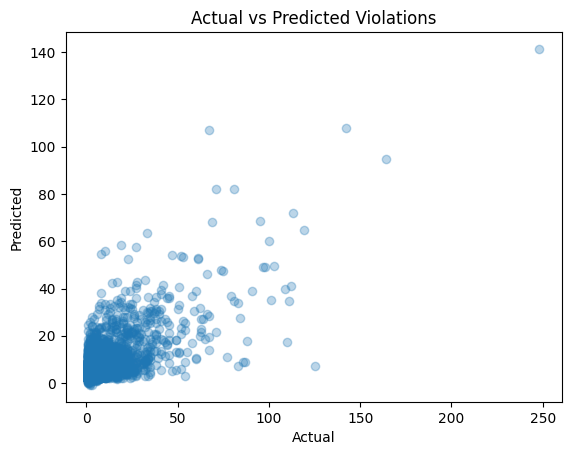

In [43]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Violations")
plt.show()

In [44]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    preds
)

print("MAPE:", mape)

MAPE: 1.4171710804027837


# **Testing**

In [45]:
sample = pd.DataFrame({
    'junction_name':['BTP082 - KR Market Junction'],
    'police_station':['City Market'],
    'hour':[19],
    'weekday':['Sunday'],
    'month':['January']
})

model.predict(sample)

array([30.38473635])

# **Saving model**

In [46]:
import joblib

joblib.dump(
    model,
    'parking_hotspot_model.pkl'
)

['parking_hotspot_model.pkl']

In [47]:
model_df.to_csv(
    "model_data.csv",
    index=False
)

In [48]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.get_feature_importance()
})

feature_importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
2,hour,31.468275
1,police_station,28.374493
0,junction_name,26.964111
4,month,7.327078
3,weekday,5.866043


In [49]:
model_df['risk_level'] = pd.cut(
    model_df['risk_score'],
    bins=[0,25,50,75,100],
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ],
    include_lowest=True
)

In [50]:
model_df[
    ['violations','risk_score','risk_level']
].head()

,violations,risk_score,risk_level
0,17,5.673759,Low
1,1,0.000000,Low
2,20,6.737589,Low
3,1,0.000000,Low
4,2,0.354610,Low


In [51]:
hotspot_summary = (
    model_df
    .groupby(
        ['junction_name','police_station']
    )
    .agg({
        'violations':'sum',
        'risk_score':'mean'
    })
    .reset_index()
)

In [52]:
hotspot_summary.sort_values(
    'risk_score',
    ascending=False
).head(20) #top hotspots

,junction_name,police_station,violations,risk_score
66,BTP051 - Safina Plaza Junction,Shivajinagar,15298,10.626813
51,BTP040 - Elite Junction,Upparpet,10718,6.631988
59,BTP044 - Sagar Theatre Junction,Upparpet,10049,6.232220
105,BTP082 - KR Market Junction,City Market,10109,5.731556
18,BTP020 - Hosahalli Metro Station,Vijayanagara,4035,5.234652
37,BTP032 - Windsor Circle,High ground,2429,4.484421
132,"BTP101 - Blood Bank Circle, KH Road",Ashok Nagar,381,4.304231
80,BTP058 - Subbanna Junction,Upparpet,4830,4.129071
12,"BTP016 - 5th Main Road, RPC Layout",Vijayanagara,2464,3.617021
282,BTP211 - Central Street Junction,Shivajinagar,5373,3.573883


Module 1 (Risk Map)

input- junction, output- risk score

In [53]:
def predict_hotspot(
    junction,
    police_station,
    hour,
    weekday,
    month
):

    sample = pd.DataFrame({
        'junction_name':[junction],
        'police_station':[police_station],
        'hour':[hour],
        'weekday':[weekday],
        'month':[month]
    })

    prediction = model.predict(sample)[0]

    return prediction

In [54]:
predict_hotspot(
    "BTP082 - KR Market Junction",
    "City Market",
    19,
    "Sunday",
    "January"
)

np.float64(30.38473634878318)

In [55]:
# Top 10 Hotspots Tomorrow

future_predictions = []

for junction in model_df['junction_name'].unique():

    station = (
        model_df[
            model_df['junction_name']==junction
        ]['police_station']
        .mode()[0]
    )

    pred = model.predict(
        pd.DataFrame({
            'junction_name':[junction],
            'police_station':[station],
            'hour':[19],
            'weekday':['Sunday'],
            'month':['January']
        })
    )[0]

    future_predictions.append(
        [junction,station,pred]
    )

future_df = pd.DataFrame(
    future_predictions,
    columns=[
        'junction',
        'station',
        'predicted_violations'
    ]
)

future_df.sort_values(
    'predicted_violations',
    ascending=False
).head(10)

,junction,station,predicted_violations
56,BTP082 - KR Market Junction,City Market,30.384736
34,BTP051 - Safina Plaza Junction,Shivajinagar,29.259119
39,BTP058 - Subbanna Junction,Upparpet,22.863865
10,BTP020 - Hosahalli Metro Station,Vijayanagara,15.571912
30,BTP044 - Sagar Theatre Junction,Upparpet,14.416281
7,"BTP016 - 5th Main Road, RPC Layout",Vijayanagara,12.851556
26,BTP040 - Elite Junction,Upparpet,11.479083
28,BTP042 - Minsk Square Junction (CTO),Shivajinagar,11.244148
154,BTP211 - Central Street Junction,Shivajinagar,10.858900
19,BTP032 - Windsor Circle,High ground,10.337835


Module 2 (Forecast)

input- date+hour, output- top 10 junctions

In [56]:
def forecast_hotspots(
    hour,
    weekday,
    month,
    top_n=10
):

    predictions = []

    junction_station_map = (
        model_df[
            ['junction_name','police_station']
        ]
        .drop_duplicates()
    )

    for _, row in junction_station_map.iterrows():

        junction = row['junction_name']
        station = row['police_station']

        pred = predict_hotspot(
            junction=junction,
            police_station=station,
            hour=hour,
            weekday=weekday,
            month=month
        )

        predictions.append([
            junction,
            station,
            pred
        ])

    forecast_df = pd.DataFrame(
        predictions,
        columns=[
            'junction_name',
            'police_station',
            'predicted_violations'
        ]
    )

    forecast_df['risk_score'] = (
        forecast_df['predicted_violations']
        /
        forecast_df['predicted_violations'].max()
    ) * 100

    return (
        forecast_df
        .sort_values(
            'predicted_violations',
            ascending=False
        )
        .head(top_n)
    )

In [57]:
# testing

forecast_hotspots(
    hour=19,
    weekday='Sunday',
    month='January'
)

,junction_name,police_station,predicted_violations,risk_score
105,BTP082 - KR Market Junction,City Market,30.384736,100.000000
66,BTP051 - Safina Plaza Junction,Shivajinagar,29.259119,96.295451
80,BTP058 - Subbanna Junction,Upparpet,22.863865,75.247863
18,BTP020 - Hosahalli Metro Station,Vijayanagara,15.571912,51.249125
59,BTP044 - Sagar Theatre Junction,Upparpet,14.416281,47.445800
12,"BTP016 - 5th Main Road, RPC Layout",Vijayanagara,12.851556,42.296092
51,BTP040 - Elite Junction,Upparpet,11.479083,37.779111
54,BTP042 - Minsk Square Junction (CTO),Shivajinagar,11.244148,37.005910
282,BTP211 - Central Street Junction,Shivajinagar,10.858900,35.738008
37,BTP032 - Windsor Circle,High ground,10.337835,34.023118


Module 3 (Deployement planner)

input- police station, output- top risk junctions, recommended patrol time

In [58]:
# patrol stats

patrol_stats = (
    junction_df
    .groupby(
        [
            'police_station',
            'junction_name',
            'hour'
        ]
    )
    .size()
    .reset_index(
        name='violations'
    )
)

In [59]:
def smart_enforcement_planner(
    police_station,
    weekday,
    month,
    top_n=5
):

    station_junctions = (
        model_df[
            model_df['police_station']
            == police_station
        ]
        [['junction_name']]
        .drop_duplicates()
    )

    recommendations = []

    for junction in station_junctions['junction_name']:

        best_hour = None
        best_prediction = -1

        for hour in range(24):

            pred = predict_hotspot(
                junction,
                police_station,
                hour,
                weekday,
                month
            )

            if pred > best_prediction:

                best_prediction = pred
                best_hour = hour

        recommendations.append([
            junction,
            best_hour,
            best_prediction
        ])

    rec_df = pd.DataFrame(
        recommendations,
        columns=[
            'junction_name',
            'recommended_hour',
            'predicted_violations'
        ]
    )

    rec_df['risk_score'] = (
        rec_df['predicted_violations']
        /
        rec_df['predicted_violations'].max()
    ) * 100

    rec_df['priority'] = pd.cut(
        rec_df['risk_score'],
        bins=[0,40,70,100],
        labels=[
            'Low',
            'Medium',
            'High'
        ],
        include_lowest=True
    )

    return (
        rec_df
        .sort_values(
            'predicted_violations',
            ascending=False
        )
        .head(top_n)
    )

In [60]:
# testing

smart_enforcement_planner(
    police_station='Shivajinagar',
    weekday='Sunday',
    month='January'
)

,junction_name,recommended_hour,predicted_violations,risk_score,priority
1,BTP051 - Safina Plaza Junction,5,141.755035,100.000000,High
4,BTP211 - Central Street Junction,5,27.070656,19.096786,Low
0,BTP042 - Minsk Square Junction (CTO),23,14.863825,10.485571,Low
2,BTP171 - Indian Express (Balekundri),3,6.092513,4.297917,Low
3,BTP173 - TMC,3,5.384607,3.798530,Low


In [61]:
joblib.dump(
    scaler,
    'risk_scaler.pkl'
)

['risk_scaler.pkl']

In [62]:
forecast_hotspots(
    19,
    "Sunday",
    "January"
)

,junction_name,police_station,predicted_violations,risk_score
105,BTP082 - KR Market Junction,City Market,30.384736,100.000000
66,BTP051 - Safina Plaza Junction,Shivajinagar,29.259119,96.295451
80,BTP058 - Subbanna Junction,Upparpet,22.863865,75.247863
18,BTP020 - Hosahalli Metro Station,Vijayanagara,15.571912,51.249125
59,BTP044 - Sagar Theatre Junction,Upparpet,14.416281,47.445800
12,"BTP016 - 5th Main Road, RPC Layout",Vijayanagara,12.851556,42.296092
51,BTP040 - Elite Junction,Upparpet,11.479083,37.779111
54,BTP042 - Minsk Square Junction (CTO),Shivajinagar,11.244148,37.005910
282,BTP211 - Central Street Junction,Shivajinagar,10.858900,35.738008
37,BTP032 - Windsor Circle,High ground,10.337835,34.023118


In [63]:
smart_enforcement_planner(
    "Shivajinagar",
    "Sunday",
    "January"
)

,junction_name,recommended_hour,predicted_violations,risk_score,priority
1,BTP051 - Safina Plaza Junction,5,141.755035,100.000000,High
4,BTP211 - Central Street Junction,5,27.070656,19.096786,Low
0,BTP042 - Minsk Square Junction (CTO),23,14.863825,10.485571,Low
2,BTP171 - Indian Express (Balekundri),3,6.092513,4.297917,Low
3,BTP173 - TMC,3,5.384607,3.798530,Low
